# NACA 0012 at high angle of attack: immersed-boundary projection solver
Run all cells top to bottom. The solve cell prints progress; the default report case (350x350, 3000 iterations) takes several minutes, so try nx=ny=120, iterations=300 first.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# report case; for a quick test use nx=ny=120, iterations=300
nx, ny = 350, 350
Re, alpha_deg = 100.0, 25.0
iterations, poisson_iters = 3000, 60

Lx, Ly, U, chord, x_le = 5.0, 2.5, 1.0, 1.0, 1.35

Geometry, mask and finite-difference helpers

In [2]:
def naca_half(x):
    xc = np.clip(x, 0, 1)
    yt = 5 * 0.12 * (0.2969*np.sqrt(xc) - 0.1260*xc - 0.3516*xc**2 + 0.2843*xc**3 - 0.1036*xc**4)
    return np.where((x >= 0) & (x <= 1), yt, -1.0)

def airfoil_wall(alpha, n=401):
    b = np.linspace(0, np.pi, n)
    xc = 0.5 * (1 - np.cos(b))
    yt = naca_half(xc)
    xb = np.concatenate((xc[::-1], xc[1:]))
    yb = np.concatenate((-yt[::-1], yt[1:]))
    a = math.radians(alpha)
    xr = xb - 0.25
    return (x_le + 0.25 + np.cos(a)*xr - np.sin(a)*yb,
            np.sin(a)*xr + np.cos(a)*yb)

def airfoil_mask(x, y, alpha, dx, dy):
    a = math.radians(alpha)
    xr = np.cos(a)*(x - x_le - 0.25) + np.sin(a)*y + 0.25
    yr = -np.sin(a)*(x - x_le - 0.25) + np.cos(a)*y
    yt = naca_half(xr)
    raw = np.clip(0.5 + 0.5*(yt - np.abs(yr)) / (0.75*max(dx, dy)), 0, 1)
    return np.where(yt >= 0, raw*raw*(3 - 2*raw), 0.0)

def laplacian(f, dx, dy):
    out = np.zeros_like(f)
    out[1:-1, 1:-1] = ((f[1:-1, 2:] - 2*f[1:-1, 1:-1] + f[1:-1, :-2]) / dx**2
                       + (f[2:, 1:-1] - 2*f[1:-1, 1:-1] + f[:-2, 1:-1]) / dy**2)
    return out

def upwind_x(f, vel, dx):
    out = np.zeros_like(f)
    out[1:-1, 1:-1] = np.where(vel[1:-1, 1:-1] >= 0, (f[1:-1, 1:-1] - f[1:-1, :-2]) / dx,
                               (f[1:-1, 2:] - f[1:-1, 1:-1]) / dx)
    return out

def upwind_y(f, vel, dy):
    out = np.zeros_like(f)
    out[1:-1, 1:-1] = np.where(vel[1:-1, 1:-1] >= 0, (f[1:-1, 1:-1] - f[:-2, 1:-1]) / dy,
                               (f[2:, 1:-1] - f[1:-1, 1:-1]) / dy)
    return out

def poisson(rhs, dx, dy, n_iter, mask):
    phi = np.zeros_like(rhs)
    d = 2 * (dx**2 + dy**2)
    for _ in range(n_iter):
        old = phi.copy()
        phi[1:-1, 1:-1] = ((old[1:-1, 2:] + old[1:-1, :-2]) * dy**2 + (old[2:, 1:-1] + old[:-2, 1:-1]) * dx**2
                           - rhs[1:-1, 1:-1] * dx**2 * dy**2) / d
        phi[mask > 0.5] = 0.0
        phi[:, 0] = phi[:, 1]; phi[:, -1] = 0.0
        phi[0, :] = phi[1, :]; phi[-1, :] = phi[-2, :]
    return phi

def bc(u, v, p):
    u[:, 0] = U; v[:, 0] = 0
    u[:, -1] = u[:, -2]; v[:, -1] = v[:, -2]
    p[:, -1] = 0.0; p[:, 0] = p[:, 1]
    u[0, :] = U; u[-1, :] = U; v[0, :] = 0; v[-1, :] = 0
    p[0, :] = p[1, :]; p[-1, :] = p[-2, :]

Solve (explicit step + penalization + pressure projection)

In [3]:
x1 = np.linspace(0, Lx, nx)
y1 = np.linspace(-Ly/2, Ly/2, ny)
x, y = np.meshgrid(x1, y1)
dx, dy = x1[1] - x1[0], y1[1] - y1[0]
nu = U * chord / Re
chi = airfoil_mask(x, y, alpha_deg, dx, dy)

u, v, p = U * (1 - chi), np.zeros((ny, nx)), np.zeros((ny, nx))
dt = min(0.10 * min(dx, dy) / U, 0.18 * min(dx*dx, dy*dy) / nu)
eta = max(0.5 * dt, 1e-5)
bc(u, v, p)
fluid = chi < 0.5
a = math.radians(alpha_deg)
hist = []

for n in range(1, iterations + 1):
    us = u + dt * (-(u*upwind_x(u, u, dx) + v*upwind_y(u, v, dy)) + nu*laplacian(u, dx, dy) - chi*u/eta)
    vs = v + dt * (-(u*upwind_x(v, u, dx) + v*upwind_y(v, v, dy)) + nu*laplacian(v, dx, dy) - chi*v/eta)
    bc(us, vs, p)

    rhs = np.zeros_like(p)
    rhs[1:-1, 1:-1] = ((us[1:-1, 2:] - us[1:-1, :-2]) / (2*dx) + (vs[2:, 1:-1] - vs[:-2, 1:-1]) / (2*dy)) / dt
    phi = poisson(rhs, dx, dy, poisson_iters, chi)
    gy, gx = np.gradient(phi, dy, dx, edge_order=2)
    uc, vc = us - dt*gx, vs - dt*gy
    p += 0.25 * phi

    fx = np.sum(chi * uc / eta) * dx * dy
    fy = np.sum(chi * vc / eta) * dx * dy
    u, v = uc * (1 - chi), vc * (1 - chi)
    bc(u, v, p)

    div = np.zeros_like(u)
    div[1:-1, 1:-1] = (u[1:-1, 2:] - u[1:-1, :-2]) / (2*dx) + (v[2:, 1:-1] - v[:-2, 1:-1]) / (2*dy)
    cont = np.sqrt(np.mean(div[fluid] ** 2))
    cd = (fx*np.cos(a) + fy*np.sin(a)) / 0.5
    cl = (-fx*np.sin(a) + fy*np.cos(a)) / 0.5
    hist.append((n, cont, np.sqrt(u*u + v*v).max(), cd, cl))
    if n == 1 or n % max(1, iterations // 5) == 0:
        print(f"iter {n}: continuity={cont:.4f}  max speed={hist[-1][2]:.4f}  Cd={cd:.4f}  Cl={cl:.4f}")

hist = np.array(hist)
speed = np.sqrt(u*u + v*v)
vort = np.zeros_like(u)
vort[1:-1, 1:-1] = (v[1:-1, 2:] - v[1:-1, :-2]) / (2*dx) - (u[2:, 1:-1] - u[:-2, 1:-1]) / (2*dy)
wx, wy = airfoil_wall(alpha_deg)

iter 1: continuity=1.0289  max speed=1.0964  Cd=4.9817  Cl=-14.5803
iter 600: continuity=0.1194  max speed=1.3074  Cd=0.4070  Cl=-1.3281
iter 1200: continuity=0.1184  max speed=1.2930  Cd=0.3161  Cl=-1.3215
iter 1800: continuity=0.1187  max speed=1.2841  Cd=0.2908  Cl=-1.3205
iter 2400: continuity=0.1165  max speed=1.2741  Cd=0.2884  Cl=-1.2711
iter 3000: continuity=0.1127  max speed=1.2602  Cd=0.2949  Cl=-1.1962


Figures 1-3: convergence, force coefficients, maximum speed

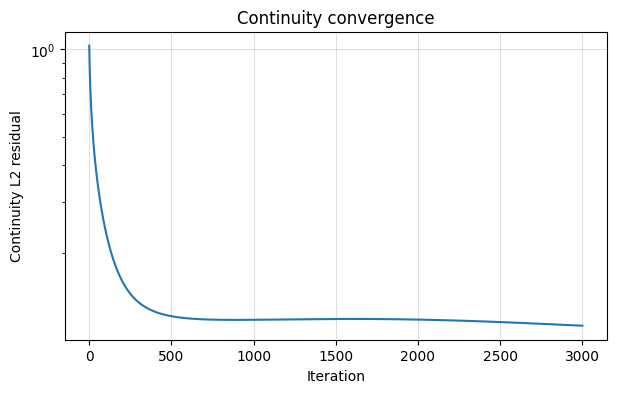

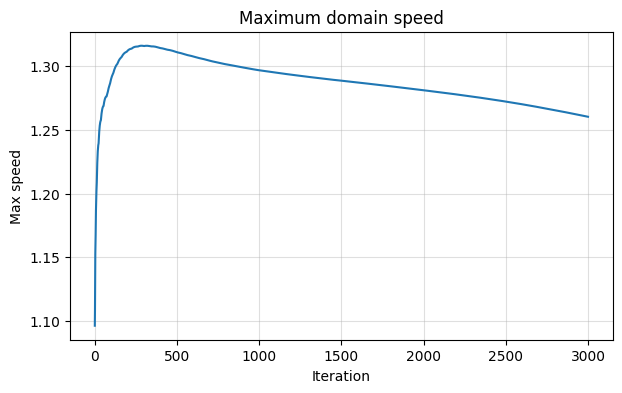

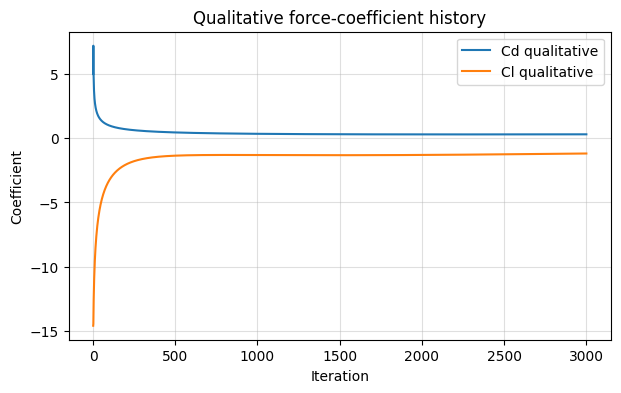

In [4]:
# Figs 1-3: histories
for col, name, ttl, log in [(1, "Continuity L2 residual", "Continuity convergence", True),
                            (2, "Max speed", "Maximum domain speed", False)]:
    plt.figure(figsize=(7, 4))
    (plt.semilogy if log else plt.plot)(hist[:, 0], hist[:, col])
    plt.xlabel("Iteration"); plt.ylabel(name); plt.title(ttl); plt.grid(alpha=0.4)
    plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist[:, 0], hist[:, 3], label="Cd qualitative")
plt.plot(hist[:, 0], hist[:, 4], label="Cl qualitative")
plt.xlabel("Iteration"); plt.ylabel("Coefficient"); plt.title("Qualitative force-coefficient history")
plt.legend(); plt.grid(alpha=0.4)
plt.show()

Figures 4-10: pressure, speed, vorticity, streamlines, vectors

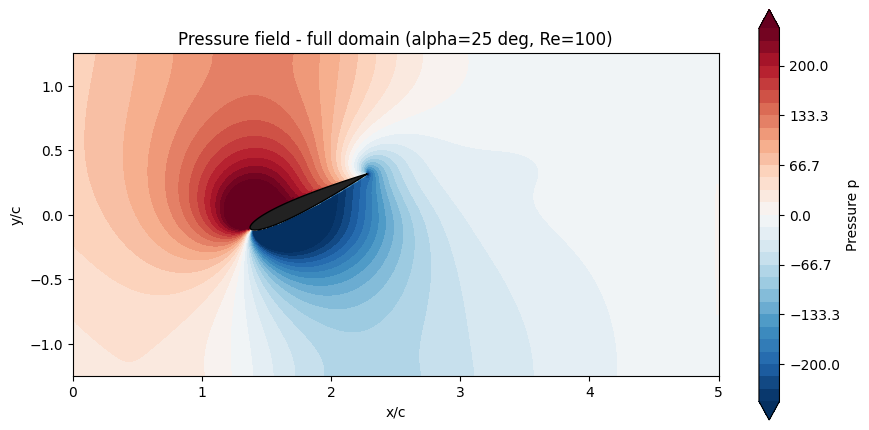

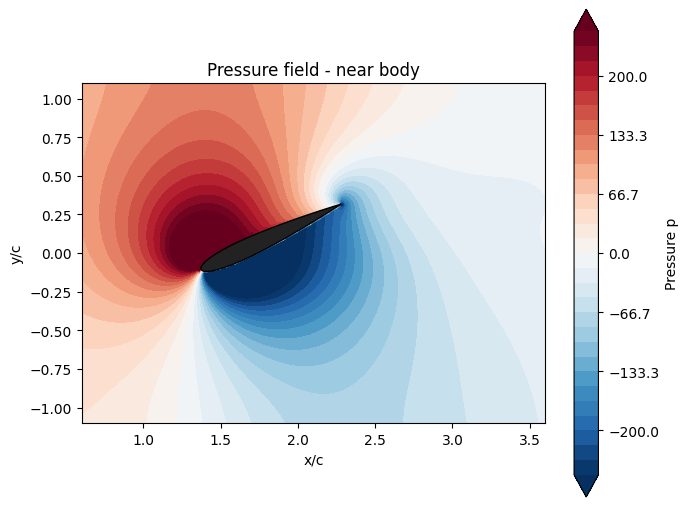

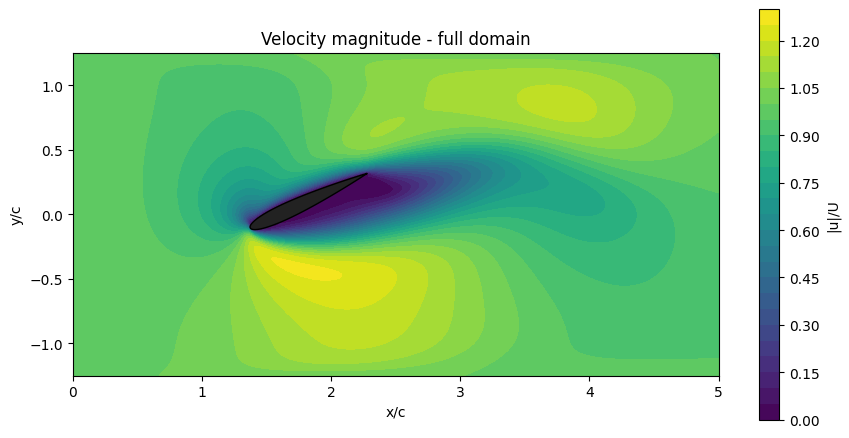

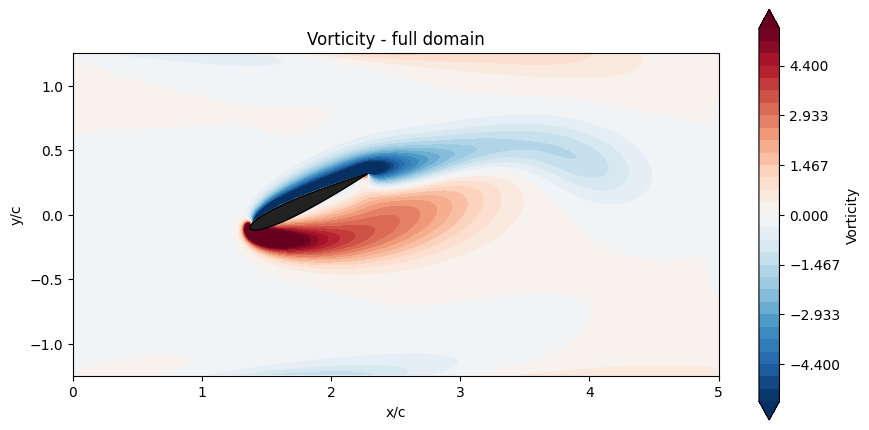

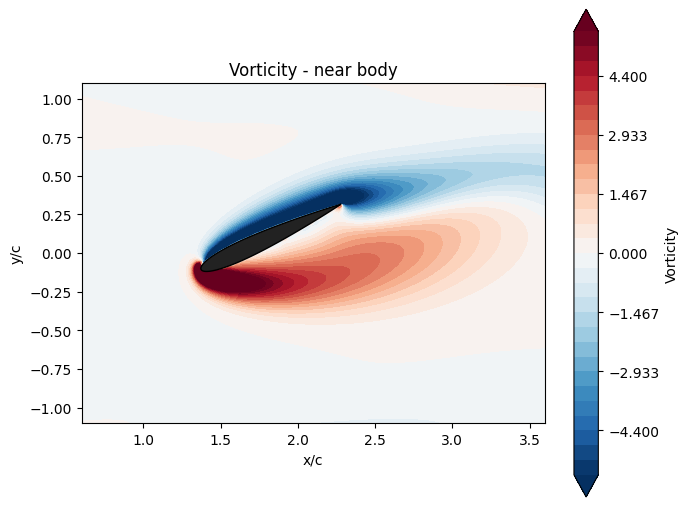

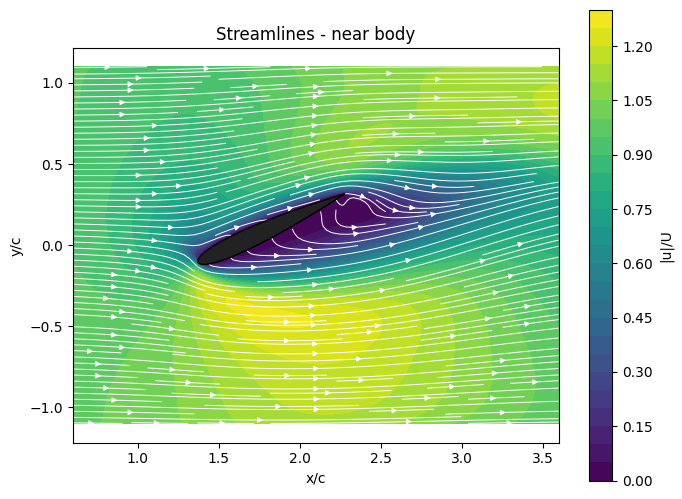

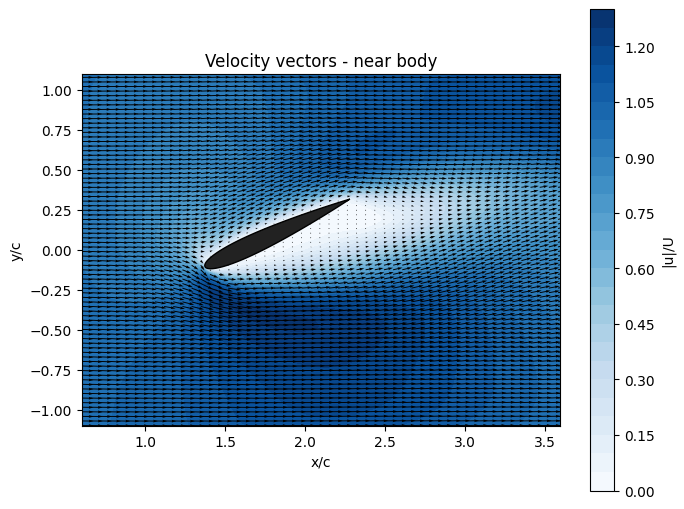

In [5]:
# Figs 4-10: fields, full domain and near-body
near = (0.6, 3.6, -1.1, 1.1)

def field(f, title, label, cmap, full=True, lim=None):
    fig, ax = plt.subplots(figsize=(9, 4.5) if full else (7, 5.2))
    kw = dict(levels=np.linspace(-lim, lim, 31), extend="both") if lim else dict(levels=30)
    cs = ax.contourf(x, y, f, cmap=cmap, **kw)
    ax.add_patch(Polygon(np.c_[wx, wy], fc="#222222", ec="k", zorder=3))
    fig.colorbar(cs, ax=ax, label=label)
    if not full:
        ax.set_xlim(near[0], near[1]); ax.set_ylim(near[2], near[3])
    ax.set(xlabel="x/c", ylabel="y/c", title=title, aspect="equal")
    plt.tight_layout(); plt.show()

field(p, f"Pressure field - full domain (alpha={alpha_deg:g} deg, Re={Re:g})", "Pressure p", "RdBu_r", lim=250)
field(p, "Pressure field - near body", "Pressure p", "RdBu_r", full=False, lim=250)
field(speed, "Velocity magnitude - full domain", "|u|/U", "viridis")
field(vort, "Vorticity - full domain", "Vorticity", "RdBu_r", lim=5.5)
field(vort, "Vorticity - near body", "Vorticity", "RdBu_r", full=False, lim=5.5)

# streamlines and vectors, near body
ix = (x1 >= near[0]) & (x1 <= near[1]); iy = (y1 >= near[2]) & (y1 <= near[3])
xs, ys, us_, vs_, ss = x1[ix], y1[iy], u[np.ix_(iy, ix)], v[np.ix_(iy, ix)], speed[np.ix_(iy, ix)]

fig, ax = plt.subplots(figsize=(7, 5.2))
cs = ax.contourf(xs, ys, ss, levels=30, cmap="viridis")
ax.streamplot(xs, ys, us_, vs_, color="white", density=2, linewidth=0.7, arrowsize=0.8)
ax.add_patch(Polygon(np.c_[wx, wy], fc="#222222", ec="k", zorder=3))
fig.colorbar(cs, ax=ax, label="|u|/U")
ax.set(xlabel="x/c", ylabel="y/c", title="Streamlines - near body", aspect="equal")
plt.tight_layout(); plt.show()

k = max(1, len(xs) // 45)
fig, ax = plt.subplots(figsize=(7, 5.2))
cs = ax.contourf(xs, ys, ss, levels=30, cmap="Blues")
ax.quiver(xs[::k], ys[::k], us_[::k, ::k], vs_[::k, ::k], scale=40, width=0.002)
ax.add_patch(Polygon(np.c_[wx, wy], fc="#222222", ec="k", zorder=3))
fig.colorbar(cs, ax=ax, label="|u|/U")
ax.set(xlabel="x/c", ylabel="y/c", title="Velocity vectors - near body", aspect="equal")
plt.tight_layout(); plt.show()

Figure 11: mask

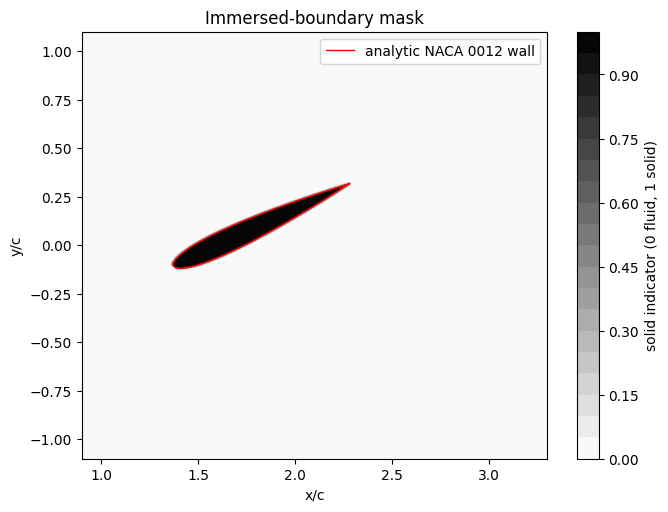

In [6]:
# Fig 11: smoothed solid mask with the analytic wall
fig, ax = plt.subplots(figsize=(7, 5.2))
cs = ax.contourf(x, y, chi, levels=20, cmap="gray_r")
ax.plot(wx, wy, "r", lw=1, label="analytic NACA 0012 wall")
fig.colorbar(cs, ax=ax, label="solid indicator (0 fluid, 1 solid)")
ax.set(xlim=(0.9, 3.3), ylim=(-1.1, 1.1), xlabel="x/c", ylabel="y/c", title="Immersed-boundary mask", aspect="equal")
ax.legend(); plt.tight_layout(); plt.show()